# 桃園市空品 PM2.5 預測模型建置

依據《桃園市空品即時預測模型訓練與建置》專案計畫書，接續資料蒐集階段（見 `README.md`），
使用 `data/raw_historical/長表格式/taoyuan_air_qulity.csv`（桃園、平鎮、大園、觀音、龍潭 5 站，2025 全年逐時資料）進行：

1. EDA（探索式資料分析）
2. 空值 / 異常值處理
3. 特徵工程
4. 依時間切分訓練 / 測試集（切分點：`2025-11-01`，之後為測試集）
5. 建立數個簡單模型並比較成效

目標變數（target）：**PM2.5**，以同時刻其他測項（PM10、O3、CO、SO2、NO2、風速、風向、氣溫、濕度）
與時間特徵（小時、月份、星期）來預測，屬於「即時 nowcasting」而非未來時序預測。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'PingFang TC', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

pd.set_option('display.max_columns', None)

## 1. 讀取資料與初步概覽

In [ ]:
df = pd.read_csv('../data/raw_historical/長表格式/taoyuan_air_qulity.csv')
print('資料筆數與欄位數:', df.shape)
df.head()

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43757 entries, 0 to 43756
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   sitename     43757 non-null  object
 1   publishtime  43757 non-null  object
 2   pm2.5        43757 non-null  object
 3   pm10         43757 non-null  object
 4   o3           43757 non-null  object
 5   co           43757 non-null  object
 6   so2          43757 non-null  object
 7   no2          43757 non-null  object
 8   wind_speed   43757 non-null  object
 9   wind_direc   43757 non-null  object
 10  amb_temp     43757 non-null  object
 11  rh           43757 non-null  object
dtypes: object(12)
memory usage: 4.0+ MB


In [4]:
df['sitename'].value_counts()

sitename
平鎮    8760
桃園    8758
龍潭    8757
觀音    8756
大園    8726
Name: count, dtype: int64

## 2. 空值與異常值處理

原始資料的測項欄位（`pm2.5`、`pm10`、`o3`...）型別皆為 `object`，因為環境部資料中混入了資料品質註記字元，
而不是單純的空字串，所以 `isna()` 完全看不出來，必須先把每欄轉成數值型態，
非數值的內容才會顯示出來。常見的註記代碼：

| 代碼 | 意義 |
|---|---|
| `#` | 儀器維護 |
| `*` | 校正 |
| `x` | 儀器故障 |
| `A` | 無效值 |

這些都不是真實觀測值，處理方式是先轉成 `NaN`，再補值。

In [5]:
value_cols = ['pm2.5', 'pm10', 'o3', 'co', 'so2', 'no2', 'wind_speed', 'wind_direc', 'amb_temp', 'rh']

# 轉換前，看看每個欄位裡有哪些非數值代碼
for c in value_cols:
    bad = df[c][pd.to_numeric(df[c], errors='coerce').isna()]
    print(f'{c:10s} 非數值代碼: {sorted(bad.unique())}  筆數: {len(bad)}')

pm2.5      非數值代碼: ['#', '*', 'A', 'x']  筆數: 578
pm10       非數值代碼: ['#', '*', 'A', 'x']  筆數: 609
o3         非數值代碼: ['#', '*', 'A', 'x']  筆數: 629
co         非數值代碼: ['#', '*', 'A', 'x']  筆數: 437
so2        非數值代碼: ['#', 'A', 'x']  筆數: 805
no2        非數值代碼: ['#', '*', 'A', 'x']  筆數: 700
wind_speed 非數值代碼: ['#']  筆數: 45
wind_direc 非數值代碼: ['#', 'x']  筆數: 73
amb_temp   非數值代碼: ['#', 'x']  筆數: 58
rh         非數值代碼: ['#', '*', 'x']  筆數: 57


In [6]:
df['publishtime'] = pd.to_datetime(df['publishtime'], format='%Y/%m/%d %H:%M:%S', errors='coerce')

for c in value_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')

missing_before = df[value_cols].isna().sum()
missing_pct = (missing_before / len(df) * 100).round(2)
pd.DataFrame({'缺值筆數': missing_before, '缺值比例(%)': missing_pct})

,缺值筆數,缺值比例(%)
pm2.5,578,1.32
pm10,609,1.39
o3,629,1.44
co,437,1.00
so2,805,1.84
no2,700,1.60
wind_speed,45,0.10
wind_direc,73,0.17
amb_temp,58,0.13
rh,57,0.13


findfont: Failed to find font weight bold, now using 400.


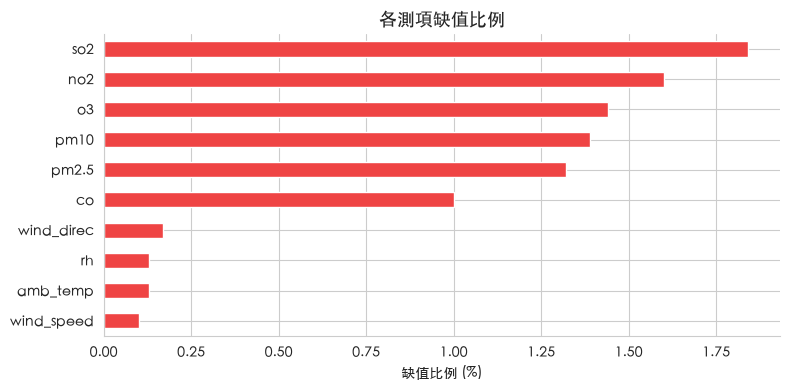

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
missing_pct.sort_values().plot(kind='barh', ax=ax, color='#EF4444')
ax.set_title('各測項缺值比例', fontsize=13, weight='bold')
ax.set_xlabel('缺值比例 (%)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

缺值比例都在 2% 以內，且是隨機分散在時間序列中的少量故障 / 維護區間。
比起直接刪除整列（會打斷時間序列，且會連帶丟掉同一列其他完好的測項），
更適合的做法是**依測站分組、沿時間排序後，用最鄰近的有效值補值（前向填補 ffill，
邊界再用後向填補 bfill 補齊）**——這也與專案原先資料整理階段（`src/imputation.py`）
採用的最鄰近值補值法一致，可維持時間序列不中斷。

In [8]:
df = df.sort_values(['sitename', 'publishtime']).reset_index(drop=True)

df[value_cols] = (
    df.groupby('sitename')[value_cols]
    .transform(lambda g: g.ffill().bfill())
)

print('補值後剩餘缺值:')
print(df[value_cols].isna().sum())
print('\npublishtime 剩餘缺值:', df['publishtime'].isna().sum())


補值後剩餘缺值:
pm2.5         0
pm10          0
o3            0
co            0
so2           0
no2           0
wind_speed    0
wind_direc    0
amb_temp      0
rh            0
dtype: int64

publishtime 剩餘缺值: 0


In [9]:
# publishtime 若有解析失敗（極少數），因為缺乏時間軸無法補值，直接捨棄
df = df.dropna(subset=['publishtime']).reset_index(drop=True)
print('最終資料筆數:', df.shape)

最終資料筆數: (43757, 12)


## 3. 探索式資料分析（EDA）

In [10]:
df[value_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
pm2.5,43757.0,11.950202,8.548067,0.00,6.00,10.00,16.0,91.00
pm10,43757.0,25.263318,18.873906,0.00,14.00,21.00,31.0,245.00
o3,43757.0,32.094949,16.559354,0.00,19.00,33.50,42.8,110.40
co,43757.0,0.243251,0.122076,0.02,0.16,0.22,0.3,2.05
so2,43757.0,1.126464,0.766364,0.00,0.60,1.00,1.5,18.40
no2,43757.0,10.252245,6.536760,0.50,5.80,8.70,13.0,74.70
wind_speed,43757.0,2.879734,2.011942,0.20,1.30,2.40,3.9,15.30
wind_direc,43757.0,135.756245,95.068711,0.00,58.00,92.00,220.0,360.00
amb_temp,43757.0,23.609635,6.115696,6.80,18.50,24.20,28.8,37.10
rh,43757.0,76.069840,15.226324,14.00,65.00,77.00,88.0,100.00


### 3.1 PM2.5 全年日均趨勢（5 站比較）

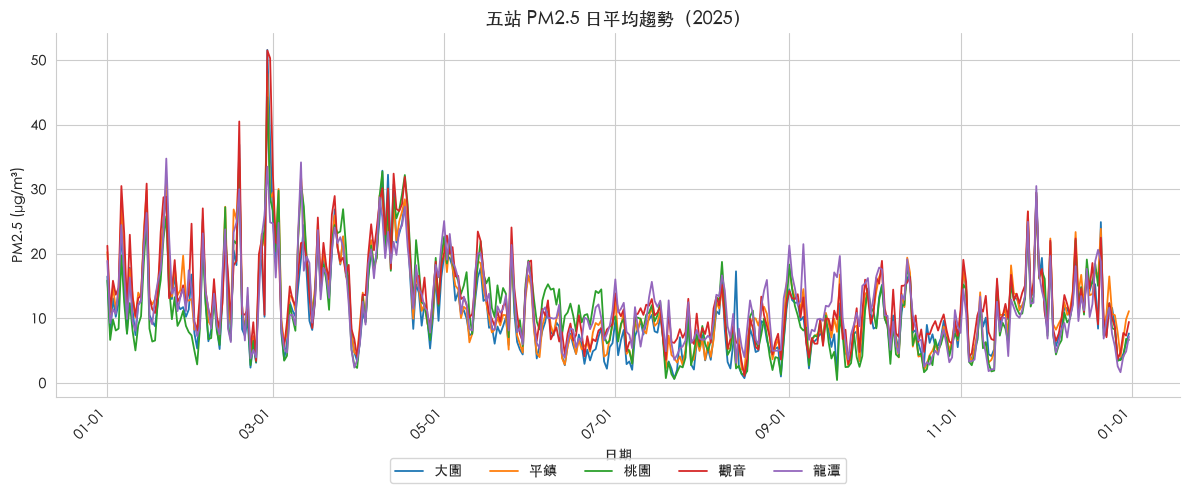

In [11]:
daily_by_site = (
    df.set_index('publishtime')
    .groupby('sitename')['pm2.5']
    .resample('D')
    .mean()
    .unstack('sitename')
)

fig, ax = plt.subplots(figsize=(12, 5))
for site in daily_by_site.columns:
    ax.plot(daily_by_site.index, daily_by_site[site], linewidth=1.3, label=site)
ax.set_title('五站 PM2.5 日平均趨勢（2025）', fontsize=13, weight='bold')
ax.set_xlabel('日期')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
ax.legend(ncol=5, loc='upper center', bbox_to_anchor=(0.5, -0.15))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.show()

### 3.2 各測站 PM2.5 分布

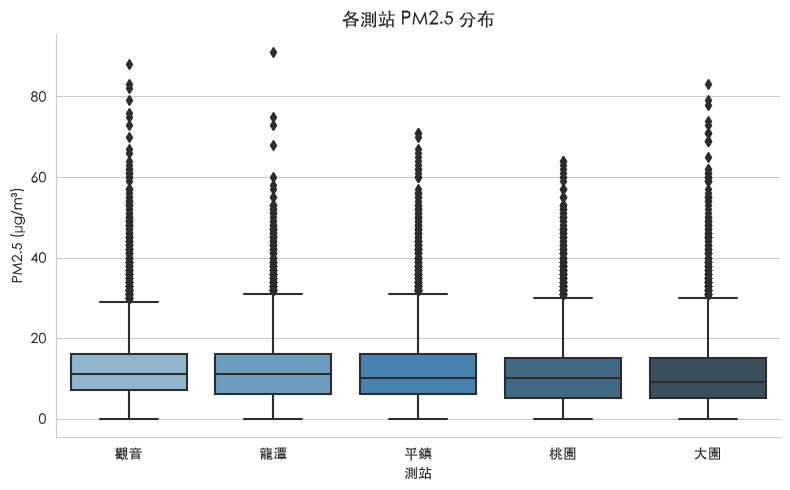

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
order = df.groupby('sitename')['pm2.5'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='sitename', y='pm2.5', order=order, ax=ax, palette='Blues_d')
ax.set_title('各測站 PM2.5 分布', fontsize=13, weight='bold')
ax.set_xlabel('測站')
ax.set_ylabel('PM2.5 (μg/m³)')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 3.3 日內時段變化（是否有交通尖峰特徵）

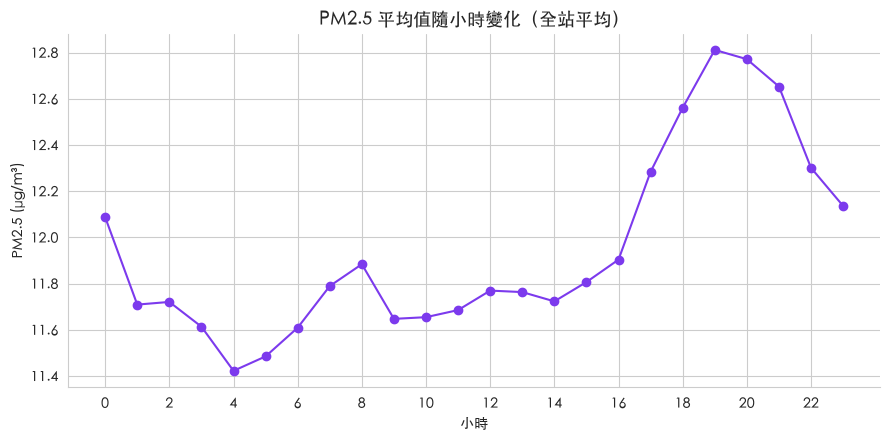

In [13]:
df['hour'] = df['publishtime'].dt.hour

fig, ax = plt.subplots(figsize=(9, 4.5))
hourly = df.groupby('hour')['pm2.5'].mean()
ax.plot(hourly.index, hourly.values, marker='o', color='#7C3AED')
ax.set_title('PM2.5 平均值隨小時變化（全站平均）', fontsize=13, weight='bold')
ax.set_xlabel('小時')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_xticks(range(0, 24, 2))
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

### 3.4 測項相關性

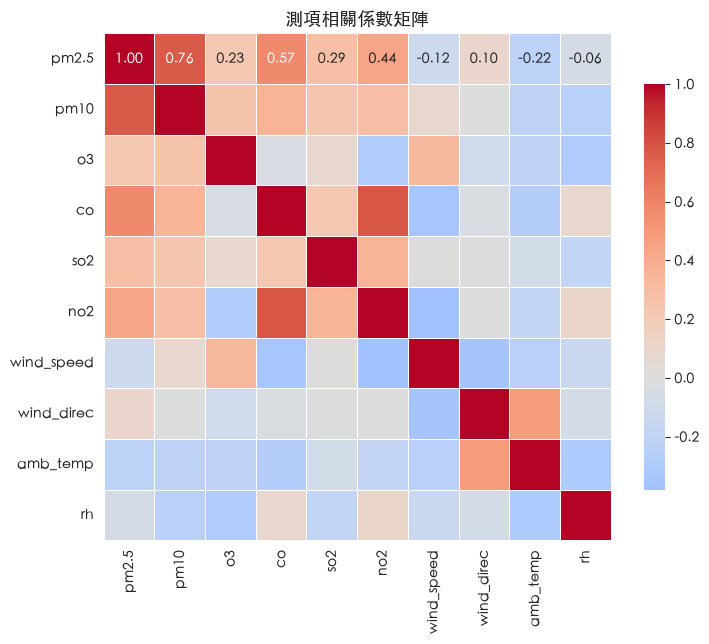

In [14]:
corr = df[value_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('測項相關係數矩陣', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

PM10 與 PM2.5 的相關性最高，符合物理常識（同屬懸浮微粒，PM2.5 是 PM10 的子集）；風速則多半與污染物濃度呈負相關（擴散效應）。

## 4. 特徵工程

新增時間特徵（小時、月份、星期幾），並保留測站別（`sitename`）作為類別特徵——
不同測站的地理環境（工業區 / 交通樞紐 / 高海拔背景）本身就是重要的資訊。

In [15]:
df['month'] = df['publishtime'].dt.month
df['dayofweek'] = df['publishtime'].dt.dayofweek  # 0=Mon ... 6=Sun

feature_cols_numeric = ['pm10', 'o3', 'co', 'so2', 'no2', 'wind_speed', 'wind_direc',
                         'amb_temp', 'rh', 'hour', 'month', 'dayofweek']
feature_cols_categorical = ['sitename']
target_col = 'pm2.5'

df[feature_cols_numeric + feature_cols_categorical + [target_col]].head()

,pm10,o3,co,so2,no2,wind_speed,wind_direc,amb_temp,rh,hour,month,dayofweek,sitename,pm2.5
0,83.0,45.1,0.48,4.3,25.9,4.0,55.0,15.3,58.0,0,1,2,大園,35.0
1,59.0,52.4,0.37,1.8,11.3,3.8,65.0,15.4,56.0,1,1,2,大園,36.0
2,48.0,49.7,0.33,1.8,12.5,3.7,64.0,15.6,56.0,2,1,2,大園,21.0
3,50.0,46.5,0.27,1.8,10.4,3.1,49.0,15.7,57.0,3,1,2,大園,19.0
4,58.0,37.5,0.23,2.4,13.7,3.1,61.0,16.0,59.0,4,1,2,大園,17.0


## 5. 訓練 / 測試集切分（依時間切分）

依專案要求，切分點為 `2025-11-01`：**該日期（含）之後作為測試集**，之前作為訓練集。
時間切分能避免用「未來」資料訓練、預測「過去」的資料洩漏問題，更貼近模型上線後的真實情境。

In [16]:
split_date = '2025-11-01'

train_df = df[df['publishtime'] < split_date].copy()
test_df = df[df['publishtime'] >= split_date].copy()

X_train = train_df[feature_cols_numeric + feature_cols_categorical]
y_train = train_df[target_col]
X_test = test_df[feature_cols_numeric + feature_cols_categorical]
y_test = test_df[target_col]

print(f'訓練集: {X_train.shape[0]} 筆（{train_df["publishtime"].min()} ~ {train_df["publishtime"].max()}）')
print(f'測試集: {X_test.shape[0]} 筆（{test_df["publishtime"].min()} ~ {test_df["publishtime"].max()}）')

訓練集: 36439 筆（2025-01-01 00:00:00 ~ 2025-10-31 23:00:00）
測試集: 7318 筆（2025-11-01 00:00:00 ~ 2025-12-31 23:00:00）


## 6. 建立模型並比較成效

以 `ColumnTransformer` 統一前處理（數值特徵做 Min-Max 正規化、類別特徵做 One-Hot 編碼），
包成 `Pipeline` 後套用到 4 個簡單模型：

- **線性迴歸 Linear Regression**：最基礎的 baseline
- **K 近鄰迴歸 KNN Regressor**
- **決策樹 Decision Tree Regressor**
- **隨機森林 Random Forest Regressor**（專案計畫書指定模型）

評估指標：MAE、RMSE、R²（皆在測試集上計算）。

In [17]:
preprocessor = ColumnTransformer(transformers=[
    ('num', MinMaxScaler(), feature_cols_numeric),
    ('cat', OneHotEncoder(handle_unknown='ignore'), feature_cols_categorical),
])

models = {
    'Linear Regression': LinearRegression(),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=5),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocess', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    results.append({'模型': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2})
    fitted_pipelines[name] = pipe

results_df = pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)
results_df

,模型,MAE,RMSE,R2
0,Random Forest,3.066886,4.358318,0.647173
1,Linear Regression,3.175354,4.590926,0.608507
2,Decision Tree,3.788022,5.713926,0.393553
3,KNN Regressor,5.790161,8.161518,-0.237273


## 7. 模型成效比較（視覺化）

findfont: Failed to find font weight bold, now using 400.


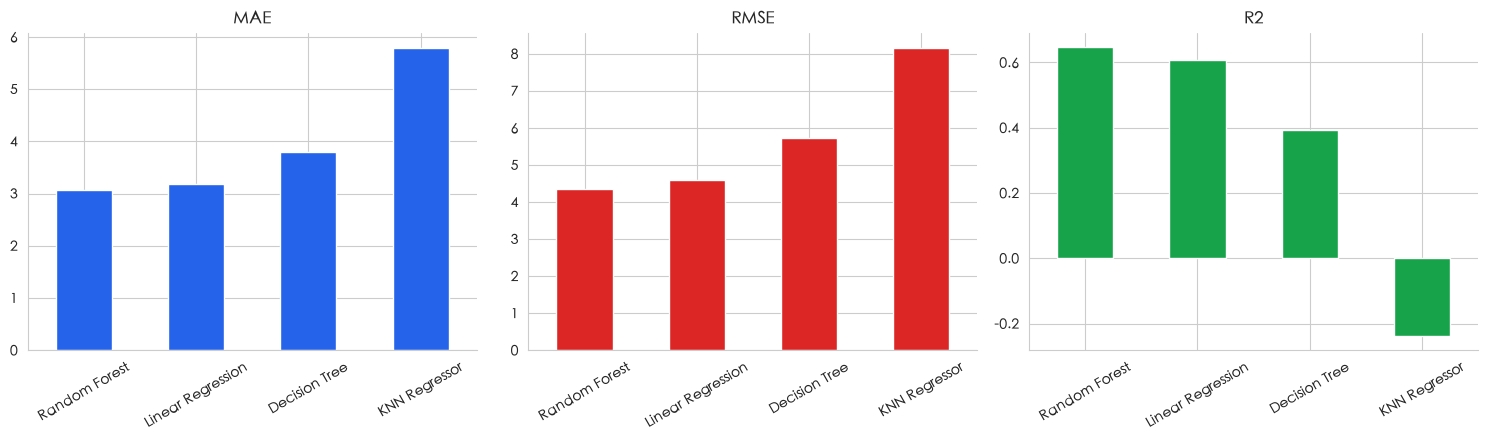

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
metrics = ['MAE', 'RMSE', 'R2']
colors = ['#2563EB', '#DC2626', '#16A34A']

plot_order = results_df.sort_values('RMSE')['模型']

for ax, metric, color in zip(axes, metrics, colors):
    data = results_df.set_index('模型').loc[plot_order, metric]
    data.plot(kind='bar', ax=ax, color=color)
    ax.set_title(metric, fontsize=12, weight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 8. 最佳模型：實際值 vs 預測值

最佳模型: Random Forest


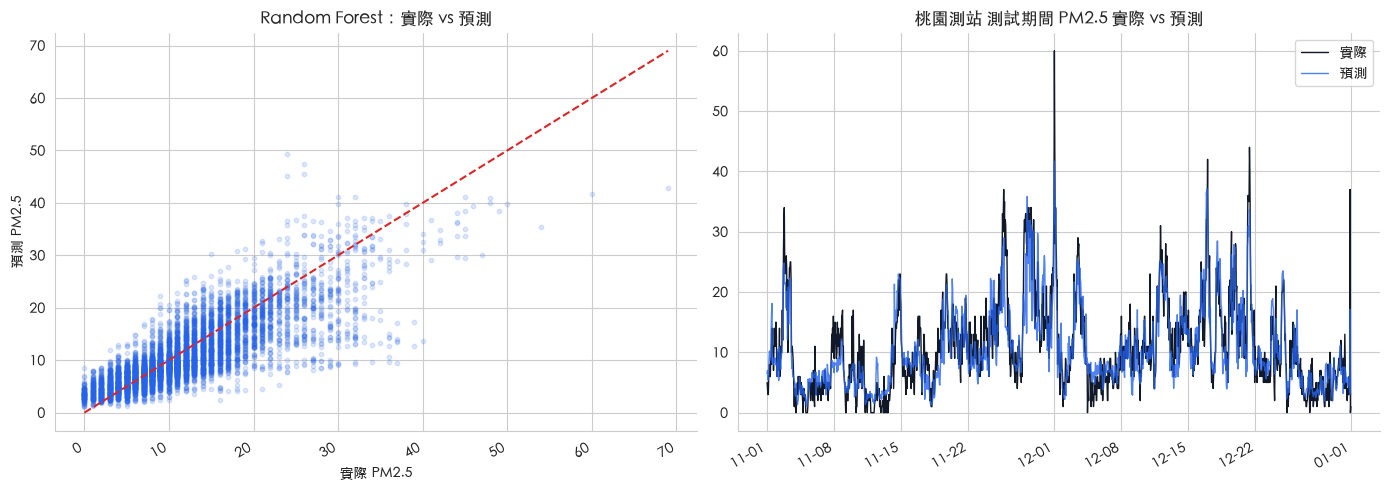

In [19]:
best_model_name = results_df.iloc[0]['模型']
best_pipe = fitted_pipelines[best_model_name]
best_pred = best_pipe.predict(X_test)

print(f'最佳模型: {best_model_name}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 散佈圖：實際 vs 預測
axes[0].scatter(y_test, best_pred, alpha=0.15, s=10, color='#2563EB')
lims = [0, max(y_test.max(), best_pred.max())]
axes[0].plot(lims, lims, color='#DC2626', linestyle='--', linewidth=1.5)
axes[0].set_xlabel('實際 PM2.5')
axes[0].set_ylabel('預測 PM2.5')
axes[0].set_title(f'{best_model_name}：實際 vs 預測', fontsize=12, weight='bold')

# 時間序列：抽一個測站看測試期間的預測貼合程度
sample_site = '桃園'
mask = test_df['sitename'] == sample_site
ts = test_df.loc[mask, 'publishtime']
axes[1].plot(ts, y_test[mask].values, label='實際', color='#111827', linewidth=1)
axes[1].plot(ts, best_pred[mask.values], label='預測', color='#2563EB', linewidth=1, alpha=0.8)
axes[1].set_title(f'{sample_site}測站 測試期間 PM2.5 實際 vs 預測', fontsize=12, weight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate(rotation=30)

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 9. 特徵重要性（Random Forest）

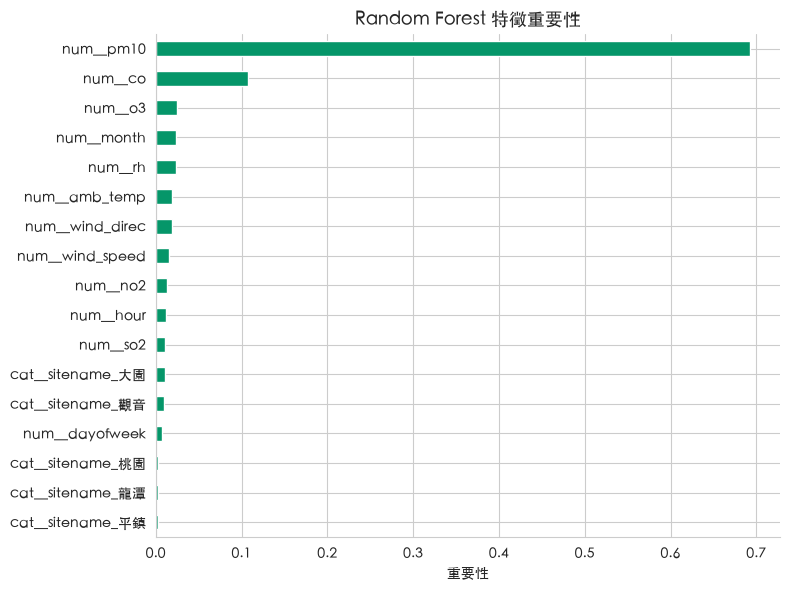

In [20]:
rf_pipe = fitted_pipelines['Random Forest']
feature_names = rf_pipe.named_steps['preprocess'].get_feature_names_out()
importances = rf_pipe.named_steps['model'].feature_importances_

fi = pd.Series(importances, index=feature_names).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
fi.plot(kind='barh', ax=ax, color='#059669')
ax.set_title('Random Forest 特徵重要性', fontsize=13, weight='bold')
ax.set_xlabel('重要性')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.show()

## 10. 結論

- 4 個模型在測試集（2025-11-01 之後，依時間切分）上的成效比較見第 6 節表格與第 7 節圖表。
- PM10 是預測 PM2.5 最重要的特徵，符合兩者同屬懸浮微粒、物理相關性高的常識。
- 本notebook 的模型屬於「同時刻其他測項 → PM2.5」的即時推估（nowcasting），
  尚未使用落後（lag）特徵做真正的未來時序預測；若要進一步強化為「預測未來 N 小時」，
  下一步可以加入 PM2.5 本身的落後值（lag features）與滑動平均，並改用時序交叉驗證評估。